# Set up

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install selenium
!apt-get update
!apt install chromium-chromedriver
!cp /usr/lib/chromium-browser/chromedriver /usr/bin

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.2/467.2 kB 12.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 7.4 MB/s eta 0:00:00
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [812 kB]
Get:8 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,019 kB]
Get:10 https://ppa.launchp

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException
import time

# Reload if there is error

In [ ]:
chrome_options = Options()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
driver = webdriver.Chrome(options=chrome_options)
wait = WebDriverWait(driver, 20)
driver.get('https://sso.hcmut.edu.vn/cas/login?service=https%3A%2F%2Fe-learning.hcmut.edu.vn%2Flogin%2Findex.php%3FauthCAS%3DCAS')
username = driver.find_element(By.ID, 'username')
password = driver.find_element(By.ID, 'password')
username.send_keys('010344')
password.send_keys('010344')
password.send_keys(Keys.RETURN)

# Scrape


In [ ]:
# driver.get('https://e-learning.hcmut.edu.vn/course/view.php?id=108885') # DT
driver.get("https://e-learning.hcmut.edu.vn/course/view.php?id=106649") # L


In [ ]:
links = driver.find_elements(By.CSS_SELECTOR, 'a.courseindex-link')

link_urls = [link.get_attribute('href') for link in links]

filtered_links = [link for link in link_urls if link.startswith("https://e-learning.hcmut.edu.vn/mod/quiz/view.php?id=")]

QUIZZES_RESULT_LINKS = [filtered_link.replace('view.php', 'report.php') + '&mode=overview' for filtered_link in filtered_links]

print("Links:")
for link_url in QUIZZES_RESULT_LINKS:
    print(link_url)

Links:
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=186547&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=186548&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=186549&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=186550&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=186551&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=192452&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=192469&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=192495&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=192498&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=192500&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=192501&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=196917&mode=overview
https://e-learning.hcmut.edu.vn/mod/quiz/report.php?id=196914&mode=overview
https

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

def parse_score(name):
    return float(name.split('\n')[1][1:])
def check(data):
    data = data["attemps"]
    print(f"Checking: n={len(data)}, sample: {data[0]}")

In [ ]:
!mkdir l

In [ ]:
for quiz_link in QUIZZES_RESULT_LINKS[21:]:

    driver.get(quiz_link)
    print(driver.title)

    input_field = driver.find_elements(By.ID, "id_pagesize")

    # Clear the current value
    input_field[0].clear()

    # Set the new value to '100'
    input_field[0].send_keys("100")

    # Simulate pressing the Enter key
    input_field[0].send_keys(Keys.ENTER)

    if "Backup" in driver.title or "Bù" in driver.title or "SEB" in driver.title:
        print("\tPASS")
        continue

    records = []

    table = driver.find_elements(By.CSS_SELECTOR, 'table.generaltable')
    headers = table[0].find_elements(By.TAG_NAME, 'th')

    students = table[0].find_elements(By.TAG_NAME, 'tr')

    for student in students[1:-2]:
        try:
            cells = student.find_elements(By.TAG_NAME, 'td')
            review_link = cells[2].find_elements(By.CSS_SELECTOR, 'a.reviewlink')[0].get_attribute('href')
            id = cells[3].text
            records.append((id, review_link))
        except:
            continue

    print(records)

    column_names = [header.text for header in headers[9:]]
    max_scores = [parse_score(column_name) for column_name in column_names]

    student_attemps = []
    n_students = len(records)

    i = 1

    for id, review_link in records:
        print(f"\r{i}/{n_students}", end='')
        driver.get(review_link)

        wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, '.que .history table')))

        tables = driver.find_elements(By.CSS_SELECTOR, '.que .history table')

        record_on_questions = []

        for table in tables:
            record_on_question = []
            rows = table.find_elements(By.TAG_NAME, 'tr')
            for row in rows:
                cells = row.find_elements(By.TAG_NAME, 'td')
                if len(cells) >= 4 and cells[2].text.startswith("Submit"):
                    record_on_question.append(cells[4].text)
            record_on_questions.append(record_on_question)

        student_attemps.append({
            "id": id,
            "records": record_on_questions
        })
        i += 1

    print()

    data = {
        "max_scores": max_scores,
        "attemps": student_attemps
    }

    check(data)

    with open(f"dt/{driver.title.replace(' ', '_').split(':')[0]}.json", "w") as json_file:
        json.dump(data, json_file)


B-Tree
[('2211648', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597139'), ('2210762', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597152'), ('2212136', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597153'), ('2213995', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597163'), ('2211729', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597173'), ('2210737', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597183'), ('2213659', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597214'), ('2112796', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597247'), ('2212495', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597311'), ('2213810', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597342'), ('2211909', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?attempt=1597368'), ('2211194', 'https://e-learning.hcmut.edu.vn/mod/quiz/review.php?att

In [ ]:
!cp -r dt drive/MyDrive/DSA-SIMULATOR/data

# Question *plot*

In [ ]:
!mkdir plots

Array_List.json
[['2.00'], ['0.40', '0.40', '2.00'], ['2.00'], ['0.00', '2.00'], ['0.00', '0.40', '1.80', '2.00'], ['0.00', '0.00', '0.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00'], ['2.00'], ['1.80', '2.00'], ['2.00'], ['2.00'], ['2.00'], ['0.00', '2.00'], ['0.00', '0.00', '0.00', '0.00'], ['2.00'], ['2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00'], ['0.00', '0.60', '0.80', '0.80', '0.80', '0.80', '0.80', '0.80', '0.80', '0.80', '0.80'], [], ['0.40', '0.40', '2.00'], ['2.00'], ['0.00', '0.00', '0.00', '0.00', '0.00', '2.00'], ['2.00'], ['2.00'], ['2.00'], ['0.00'], [], []]
[['1.80', '2.00'], ['0.00', '0.00', '2.00'], ['1.80', '2.00'], ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '2.00', '2.00'], ['1.80', '1.80', '2.00'], ['2.00'], ['1.80', '1.80', '1.80', '2.00'], ['0.40', '0.40'], ['2.00'], ['0.00', '0.40', '0.40', '2.00'], ['2.00'], ['2.00'], ['1.80', '1.80', '1.80'], ['2.00'], 

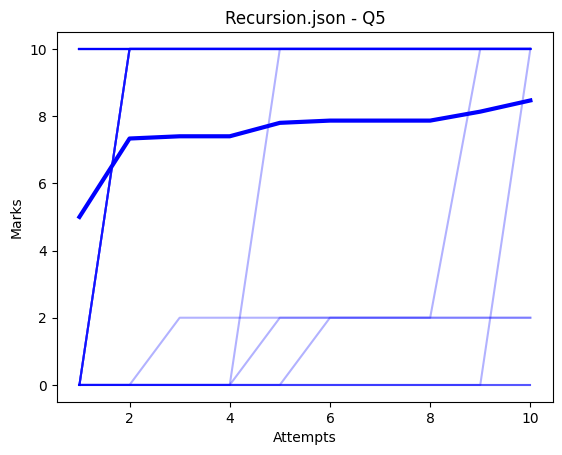

In [ ]:
for json_file in os.listdir("drive/MyDrive/DSA-SIMULATOR/data/DT"):
    if json_file == ".ipynb_checkpoints":
        continue

    name = json_file
    print(name)
    json_file = os.path.join("drive/MyDrive/DSA-SIMULATOR/data/DT", json_file)
    with open(json_file, "r") as f:
        data = json.load(f)

    '''
    data = {
        "max_scores": max_scores, // list of maximum scores of each question, len(max_scores) = number of question
        "attemps": {
            [
                {
                    "id": student_id,
                    "records": [  // list of list of submitting records, len(records) = number of question
                        [0, 0, 0, 2],
                        [0, 1, 2],
                        ...
                        [1, 1, 2]
                    ]
                },
                ...
            ]
        }
    }
    '''

    # Question q
    for q in range(len(data["max_scores"])):
        plt.clf()

        max_score = data["max_scores"][q]
        attemps = data["attemps"]
        ids = [attemp['id'] for attemp in attemps]
        records = [attemp['records'][q] for attemp in attemps]
        print(records)
        try:
            records = [[float(mark) * 10 / max_score for mark in student_marks] for student_marks in records]
        except:
            continue

        # Find the maximum number of attempts across all students
        max_attempts = max(len(student_marks) for student_marks in records)

        # Generate x values (attempts)
        x = list(range(1, max_attempts + 1))

        # Find the average score for each number of attemps
        # Pad the marks of each student with highest marks
        padded_records = []
        for student_marks in records:
            if student_marks:
                padded_records.append(student_marks + [max(student_marks)] * (max_attempts - len(student_marks)))
            else:
                padded_records.append([0] * max_attempts)
        # Convert the list of lists to a NumPy array
        padded_records = np.array(padded_records)
        # Calculate the average marks for each attempt number across all students
        average_marks = np.nanmean(padded_records, axis=0)

        # Plot each student's attempts
        for i, student_marks in enumerate(padded_records):
            plt.plot(x, student_marks, label=f"{ids[i]}", color='blue', alpha=0.3)

        # Plot the average marks as a bold line
        plt.plot(x, average_marks, label='Average Marks', linewidth=3, color='blue')

        # Add labels and legend
        plt.xlabel('Attempts')
        plt.ylabel('Marks')
        plt.title(f'{name} - Q{q+1}')
        # plt.legend()

        plt.savefig(f'plots/{name}-Q{q+1}.png')


In [ ]:
!cp -r plots drive/MyDrive/DSA-SIMULATOR/question-plots/

# Question plot (all question in one graph)

Find max

In [ ]:
global_max = 0

for json_file in os.listdir("drive/MyDrive/DSA-SIMULATOR/data/DT"):
    if json_file == ".ipynb_checkpoints":
        continue

    name = json_file
    print(name)
    json_file = os.path.join("drive/MyDrive/DSA-SIMULATOR/data/DT", json_file)
    with open(json_file, "r") as f:
        data = json.load(f)

    # Question q
    for q in range(len(data["max_scores"])):

        max_score = data["max_scores"][q]
        attemps = data["attemps"]
        ids = [attemp['id'] for attemp in attemps]
        records = [attemp['records'][q] for attemp in attemps]
        try:
            records = [[float(mark) * 10 / max_score for mark in student_marks] for student_marks in records]
        except:
            continue

        # Find the maximum number of attempts across all students
        max_attempts = max(len(student_marks) for student_marks in records)
        global_max = max(global_max, max_attempts)
        print(global_max)


Array_List.json
13
13
14
14
14
Singly_Linked_List.json
22
22
22
22
22
Test_SEB.json
22
Exam_1-Backup.json
22
22
22
Exam_1.json
22
22
22
Doubly_Linked_List.json
22
22
22
23
23
Queue.json
23
23
23
23
23
Stack.json
23
23
23
23
23
Sorting_(Easy).json
23
23
23
23
23
Exam_2.json
23
23
23
Sorting_(Advanced).json
23
23
23
23
23
Binary_Tree.json
23
23
23
23
23
Binary_Search_Tree.json
23
23
23
23
23
Exam_3.json
23
23
23
AVL_Tree.json
23
27
27
27
27
B-Tree.json
27
27
27
27
Exam_4.json
27
27
27
Heap.json
27
27
27
27
27
Exam_5.json
27
27
27
Search.json
27
27
27
27
Hash.json
27
27
27
Graph.json
27
27
27
27
27
OOP_Review.json
27
27
27
33
33
Recursion.json
33
33
33
33
33


Array_List.json
[[10.0], [2.0, 2.0, 10.0], [10.0], [0.0, 10.0], [0.0, 2.0, 9.0, 10.0], [0.0, 0.0, 0.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0], [10.0], [9.0, 10.0], [10.0], [10.0], [10.0], [0.0, 10.0], [0.0, 0.0, 0.0, 0.0], [10.0], [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0], [0.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0], [], [2.0, 2.0, 10.0], [10.0], [0.0, 0.0, 0.0, 0.0, 0.0, 10.0], [10.0], [10.0], [10.0], [0.0], [], []]
[[9.0, 10.0], [0.0, 0.0, 10.0], [9.0, 10.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 10.0], [9.0, 9.0, 10.0], [10.0], [9.0, 9.0, 9.0, 10.0], [2.0, 2.0], [10.0], [0.0, 2.0, 2.0, 10.0], [10.0], [10.0], [9.0, 9.0, 9.0], [10.0], [10.0], [10.0], [], [10.0], [9.0], [0.0, 0.0, 10.0], [2.0, 10.0], [], [10.0], [], [], []]
[[], [10.0], [10.0], [2.0, 6.0], [10.0], [0.0, 2.0, 2.0, 10.0], [], [0.0, 0.0, 0.0, 0.0], [10.0], [2.0, 2.0, 10.0], [10.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

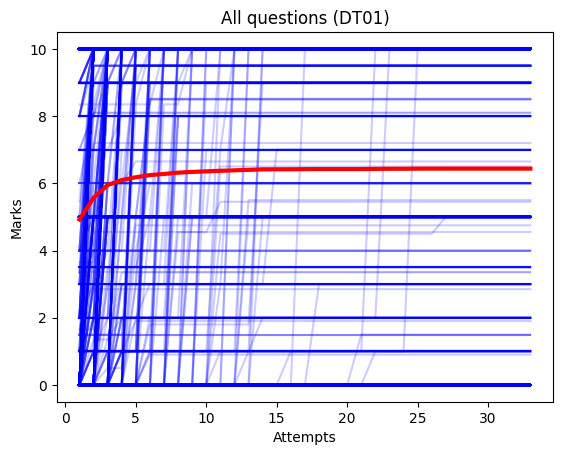

In [ ]:
plt.clf()

all_padded_records = []

for json_file in os.listdir("drive/MyDrive/DSA-SIMULATOR/data/DT"):
    if json_file == ".ipynb_checkpoints":
        continue

    name = json_file
    print(name)
    json_file = os.path.join("drive/MyDrive/DSA-SIMULATOR/data/DT", json_file)
    with open(json_file, "r") as f:
        data = json.load(f)

    '''
    data = {
        "max_scores": max_scores, // list of maximum scores of each question, len(max_scores) = number of question
        "attemps": {
            [
                {
                    "id": student_id,
                    "records": [  // list of list of submitting records, len(records) = number of question
                        [0, 0, 0, 2],
                        [0, 1, 2],
                        ...
                        [1, 1, 2]
                    ]
                },
                ...
            ]
        }
    }
    '''

    # Question q
    for q in range(len(data["max_scores"])):

        max_score = data["max_scores"][q]
        attemps = data["attemps"]
        ids = [attemp['id'] for attemp in attemps]
        records = [attemp['records'][q] for attemp in attemps]
        try:
            if name == 'Graph.json':
                max_score = 2
            records = [[float(mark) * 10 / max_score for mark in student_marks] for student_marks in records]
        except:
            continue
        print(records)

        # Generate x values (attempts)
        x = list(range(1, global_max + 1))

        # Find the average score for each number of attemps
        # Pad the marks of each student with highest marks
        padded_records = []
        for student_marks in records:
            if student_marks:
                padded_records.append(student_marks + [max(student_marks)] * (global_max - len(student_marks)))
                all_padded_records.append(student_marks + [max(student_marks)] * (global_max - len(student_marks)))
            else:
                padded_records.append([0] * global_max)
                all_padded_records.append([0] * global_max)

        # Convert the list of lists to a NumPy array
        padded_records = np.array(padded_records)

        # Plot each student's attempts
        for i, student_marks in enumerate(padded_records):
            plt.plot(x, student_marks, label=f"{ids[i]}", color='blue', alpha=0.2)

all_padded_records = np.array(all_padded_records)
all_average_marks = np.nanmean(all_padded_records, axis=0)
plt.plot(x, all_average_marks, label='All Average Marks', linewidth=3, color='Red')

# Add labels and legend
plt.xlabel('Attempts')
plt.ylabel('Marks')
plt.title(f'All questions (DT01)')
# plt.legend()

plt.savefig(f'all-questions.png')


# Weeks plot

In [ ]:
WEEKS = [
    [
        'OOP_Review.json',
        'Recursion.json',
        'Array_List.json',
        'Singly_Linked_List.json'
    ],
    # 'Test_SEB:_Attempt_review.json',
    [
        'Week_2_Exam.json',
        'Doubly_Linked_List.json',
        'Stack.json',
        'Queue.json',
        'Sorting_(Easy).json'
    ],
    [
        'Week_3_Exam.json',
        'Sorting_(Advance).json',
        'Binary_Tree.json',
        'Binary_Search_Tree.json'
    ],
    [
        'Week_4_Exam.json',
        'AVL_Tree.json',
        'B-Tree.json'
    ],
    [
        'Week_5_Exam.json',
        'Heap.json',
        'Search.json'
    ],
    [
        'Week_6_Exam.json',
        'Graph.json',
        'Hash.json'
    ]
    # 'Exam_1-Backup:_Attempt_review.json',
]

In [ ]:
ids_set = set()
for WEEK in WEEKS:
    for path in WEEK:
        with open('drive/MyDrive/DSA-SIMULATOR/data/L09/'+path, "r") as f:
            data = json.load(f)
            attemps = data["attemps"]
            ids = [attemp['id'] for attemp in attemps]
        ids_set.update(ids)
        print(len(ids))
print(f'-> {len(ids_set)}')

41
49
44
51
33
43
40
38
38
33
40
39
43
31
39
46
32
51
41
32
35
38
-> 40


In [ ]:
ids = list(ids_set)

In [ ]:
STUDENTS = {id: [] for id in ids}
for WEEK in WEEKS[:]:
    for id in ids:
        STUDENTS[id].append([])
    for EXERCISE in WEEK[:]:
        with open('drive/MyDrive/DSA-SIMULATOR/data/L09/'+EXERCISE, "r") as f:
            data = json.load(f)
        attemps = data["attemps"]

        this_exercise_result = {}
        ids_do_exercise = []
        for attemp in attemps:
            id = attemp['id']
            records = attemp['records']
            records: list[list]

            maxes = []
            for question_marks in records:

                # Special cases
                if EXERCISE == 'Graph.json':
                    question_marks = [float(mark) * 5 / 7 for mark in question_marks]
                if EXERCISE == 'Week_5_Exam.json':
                    question_marks = [float(mark) * 10 / 11 for mark in question_marks]

                if question_marks:
                    try:
                        maxes.append(max([float(mark) for mark in question_marks]))
                    except:
                        maxes.append(0)
                else:
                    maxes.append(0)
            print(EXERCISE, id, maxes)
            result = sum(maxes)

            student_last_result = this_exercise_result.get(id, 0)
            if result >= student_last_result:
                this_exercise_result[id] = result

            ids_do_exercise.append(id)

        for id in ids:
            if id in ids_do_exercise:
                STUDENTS[id][-1].append(this_exercise_result[id])
            else:
                STUDENTS[id][-1].append(0)


OOP_Review.json 2211909 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2211756 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2212257 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2210762 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 1913238 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2110152 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2211194 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2211452 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2211729 [2.0, 2.0, 1.67, 2.0, 2.0]
OOP_Review.json 2211644 [2.0, 2.0, 1.67, 2.0, 2.0]
OOP_Review.json 2210626 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2213995 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2210737 [2.0, 2.0, 2.0, 0.0, 0.0]
OOP_Review.json 2210901 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2212136 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2213781 [2.0, 1.8, 2.0, 2.0, 0.4]
OOP_Review.json 2212495 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2213549 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2211648 [2.0, 2.0, 2.0, 2.0, 2.0]
OOP_Review.json 2112796 [2.0, 2.0, 2.0, 2.0, 2.0

In [ ]:
STUDENTS

{'1911745': [[10.0, 8.0, 10.0, 10.0],
  [9.5, 9.8, 10.0, 10.0, 6.0],
  [10.0, 2.0, 10.0, 0],
  [0, 0, 0],
  [0, 0, 0],
  [0, 0, 0]],
 '2213781': [[10.0, 8.0, 7.6899999999999995, 6.5],
  [4.5, 6.0, 9.45, 9.8, 6.000000000000001],
  [3.73, 8.0, 8.4, 8.4],
  [6.6, 10.0, 10.0],
  [2.227272727272727, 10.0, 10.0],
  [10.0, 7.428571428571429, 6.6]],
 '2110152': [[10.0, 8.0, 10.0, 9.6],
  [8.4, 9.6, 10.0, 10.0, 6.0],
  [0, 8.0, 9.6, 8.6],
  [5.0, 9.8, 7.75],
  [0.0, 10.0, 10.0],
  [10.0, 10.0, 10.0]],
 '2210737': [[6.0, 6.0, 8.2, 6.5],
  [5.1, 6.0, 6.0, 6.0, 6.0],
  [7.73, 7.6, 7.2, 6.0],
  [5.0, 7.2, 4.5],
  [1.8181818181818181, 9.4, 6.0],
  [4.2, 4.285714285714286, 3.7]],
 '1913238': [[10.0, 8.0, 10.0, 10.0],
  [0, 9.52, 8.6, 6.2, 7.0],
  [2.27, 10.0, 10.0, 10.0],
  [0, 10.0, 7.38],
  [0, 9.8, 10.0],
  [4.0, 8.571428571428571, 10.0]],
 '2111013': [[0, 0, 0, 0],
  [0.0, 4.4, 7.0, 8.2, 4.0],
  [0, 0, 0, 0],
  [0, 0, 0],
  [0, 0, 0],
  [0, 0, 0]],
 '2212136': [[10.0, 6.0, 10.0, 8.0],
  [6.0, 8.2

In [ ]:
GROUPED_BY_WEEK = STUDENTS.copy()
for id, records in GROUPED_BY_WEEK.items():
    GROUPED_BY_WEEK[id] = [sum(record) / len(record) for record in records]

In [ ]:
GROUPED_BY_WEEK

{'1911745': [9.5, 9.059999999999999, 5.5, 0.0, 0.0, 0.0],
 '2213781': [8.0475,
  7.15,
  7.1325,
  8.866666666666667,
  7.409090909090909,
  8.009523809523811],
 '2110152': [9.4,
  8.8,
  6.550000000000001,
  7.516666666666667,
  6.666666666666667,
  10.0],
 '2210737': [6.675,
  5.82,
  7.1325,
  5.566666666666666,
  5.739393939393939,
  4.061904761904763],
 '1913238': [9.5,
  6.263999999999999,
  8.067499999999999,
  5.793333333333333,
  6.6000000000000005,
  7.523809523809523],
 '2111013': [0.0, 4.720000000000001, 0.0, 0.0, 0.0, 0.0],
 '2212136': [8.5, 8.5, 9.425, 7.25, 7.545454545454546, 10.0],
 '2210961': [9.5,
  10.0,
  10.0,
  8.799999999999999,
  9.863636363636363,
  9.928571428571429],
 '2211526': [4.65,
  6.356,
  7.7325,
  3.6999999999999997,
  6.425454545454545,
  6.501904761904762],
 '2112796': [8.9,
  8.72,
  8.965,
  8.076666666666666,
  7.084848484848485,
  8.857142857142856],
 '2213860': [9.5,
  7.4799999999999995,
  9.225,
  5.066666666666666,
  7.272727272727273,
  8.

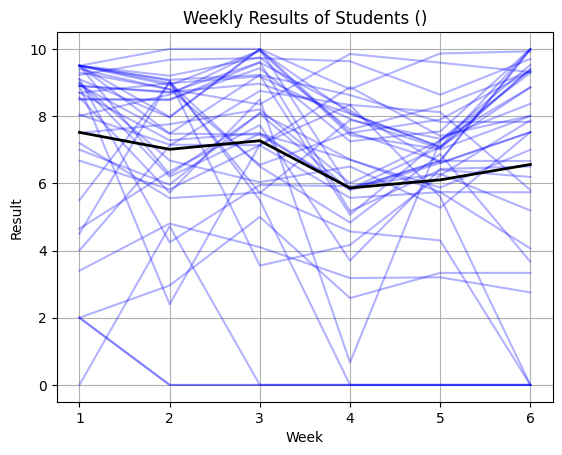

In [ ]:
# Calculate the average result for each test
num_tests = 6
avg_results = [sum(all_student_scores_in_one_week)/len(all_student_scores_in_one_week) for all_student_scores_in_one_week in zip(*GROUPED_BY_WEEK.values())]

# Generate x values (test order)
test_order = list(range(1, num_tests + 1))

# Plot each student's test results
for id, week_avg in GROUPED_BY_WEEK.items():
    plt.plot(test_order, week_avg, label=f"Student {id}", color='blue', alpha=0.3)

# Plot the average line
plt.plot(test_order, avg_results, label='Average', linewidth=2, color='black')

# Add labels and title
plt.xlabel('Week')
plt.ylabel('Result')
plt.title('Weekly Results of Students ()')
# plt.legend()

# Show the plot
plt.grid(True)
plt.show()